In [72]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [73]:
titanic=sns.load_dataset('titanic')

In [74]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [75]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [76]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [77]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [78]:
features=['pclass','sex','fare','embarked','age']
target=['survived']

In [79]:
# missing data
from sklearn.impute import SimpleImputer
imputer_median=SimpleImputer(strategy="median")
imputer_mode=SimpleImputer(strategy="most_frequent")


titanic[['age']]=imputer_median.fit_transform(titanic[['age']])
titanic[['embarked']]=imputer_mode.fit_transform(titanic[['embarked']])

In [80]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [81]:
titanic.shape

(891, 15)

In [82]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
titanic['sex']=lb.fit_transform(titanic['sex'])
titanic['embarked']=lb.fit_transform(titanic['embarked'])

In [83]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [84]:
X=titanic[features]
Y=titanic[target]

In [99]:
x_train,x_test,y_train,y_test=train_test_split(
    X,Y,test_size=0.2)

In [100]:
x_train.head()

,pclass,sex,fare,embarked,age
578,3,0,14.4583,0,28.0
178,2,1,13.0000,2,30.0
49,3,0,17.8000,2,18.0
580,2,0,30.0000,2,25.0
346,2,0,13.0000,2,40.0


In [101]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()

model.fit(x_train,y_train)

DecisionTreeClassifier()

In [102]:
from sklearn.metrics import  accuracy_score
y_pred=model.predict(x_test)

print("accuracy  :" , accuracy_score(y_test,y_pred))

accuracy  : 0.7877094972067039


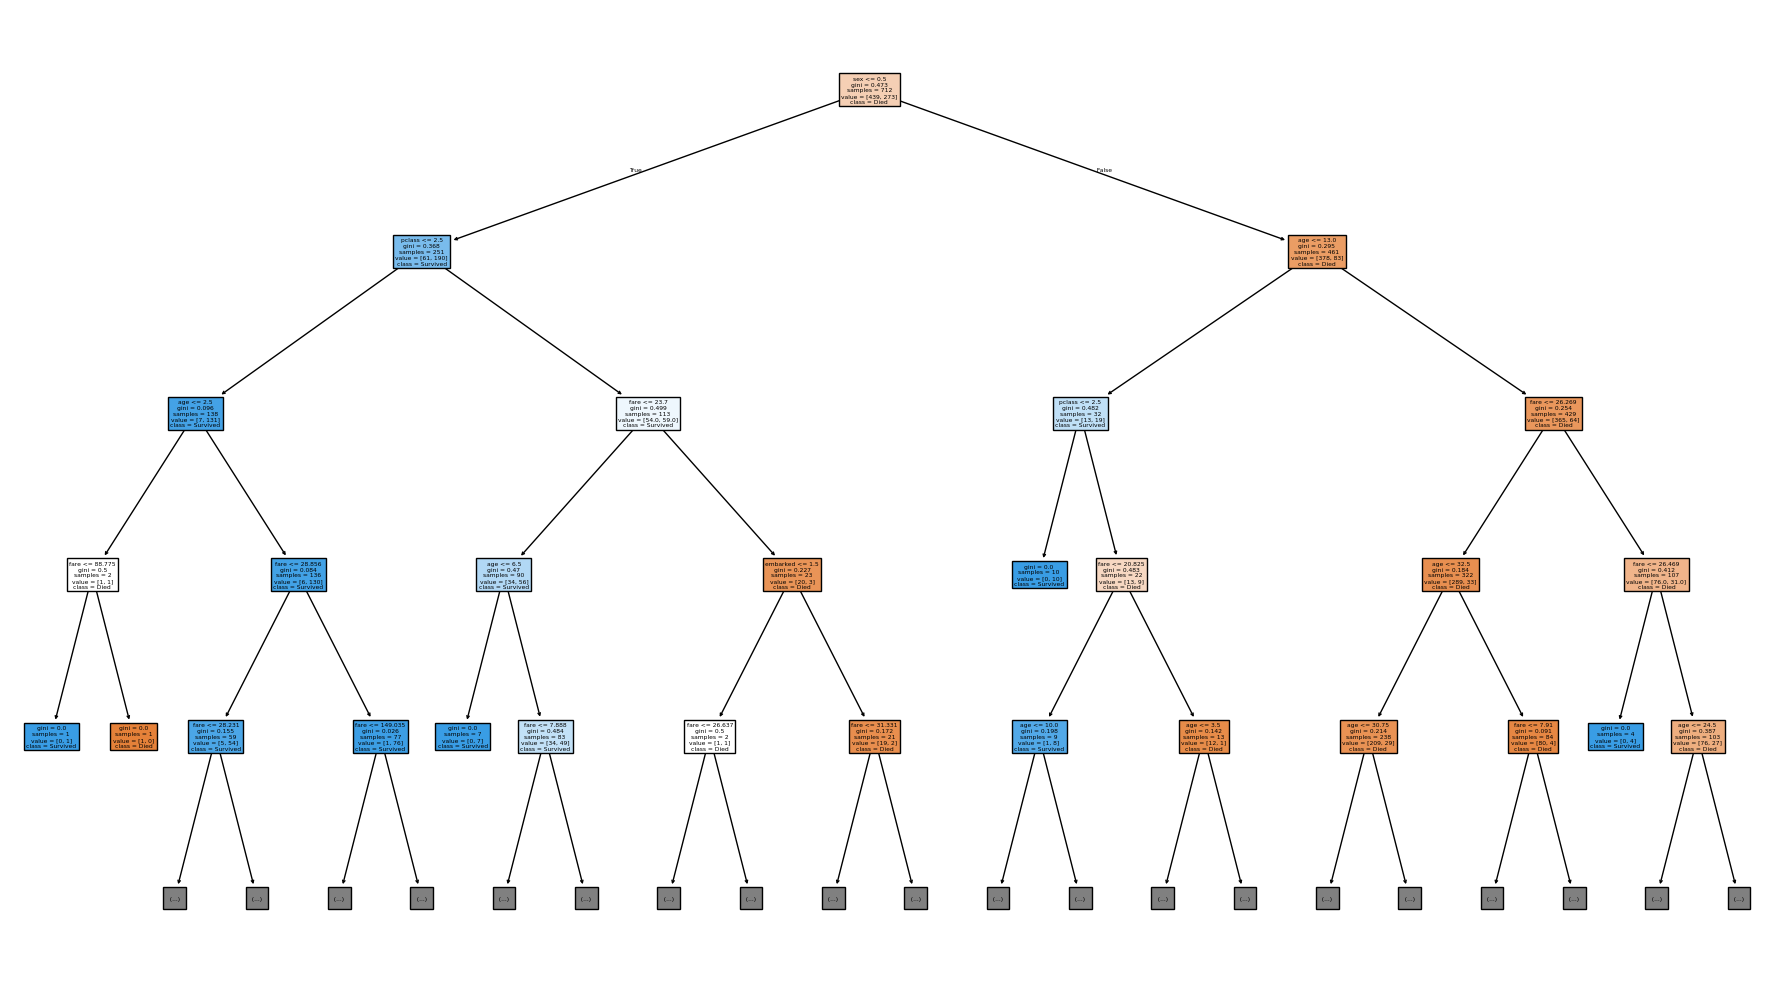

In [104]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(model,feature_names=X.columns,
          class_names=["Died","Survived"],
          filled=True,max_depth=4)
plt.tight_layout()
plt.show()

In [105]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


for depth = 2 , accuracy =0.7374301675977654
for depth = 3 , accuracy =0.770949720670391
for depth = 4 , accuracy =0.770949720670391
for depth = 5 , accuracy =0.770949720670391
for depth = 6 , accuracy =0.8156424581005587


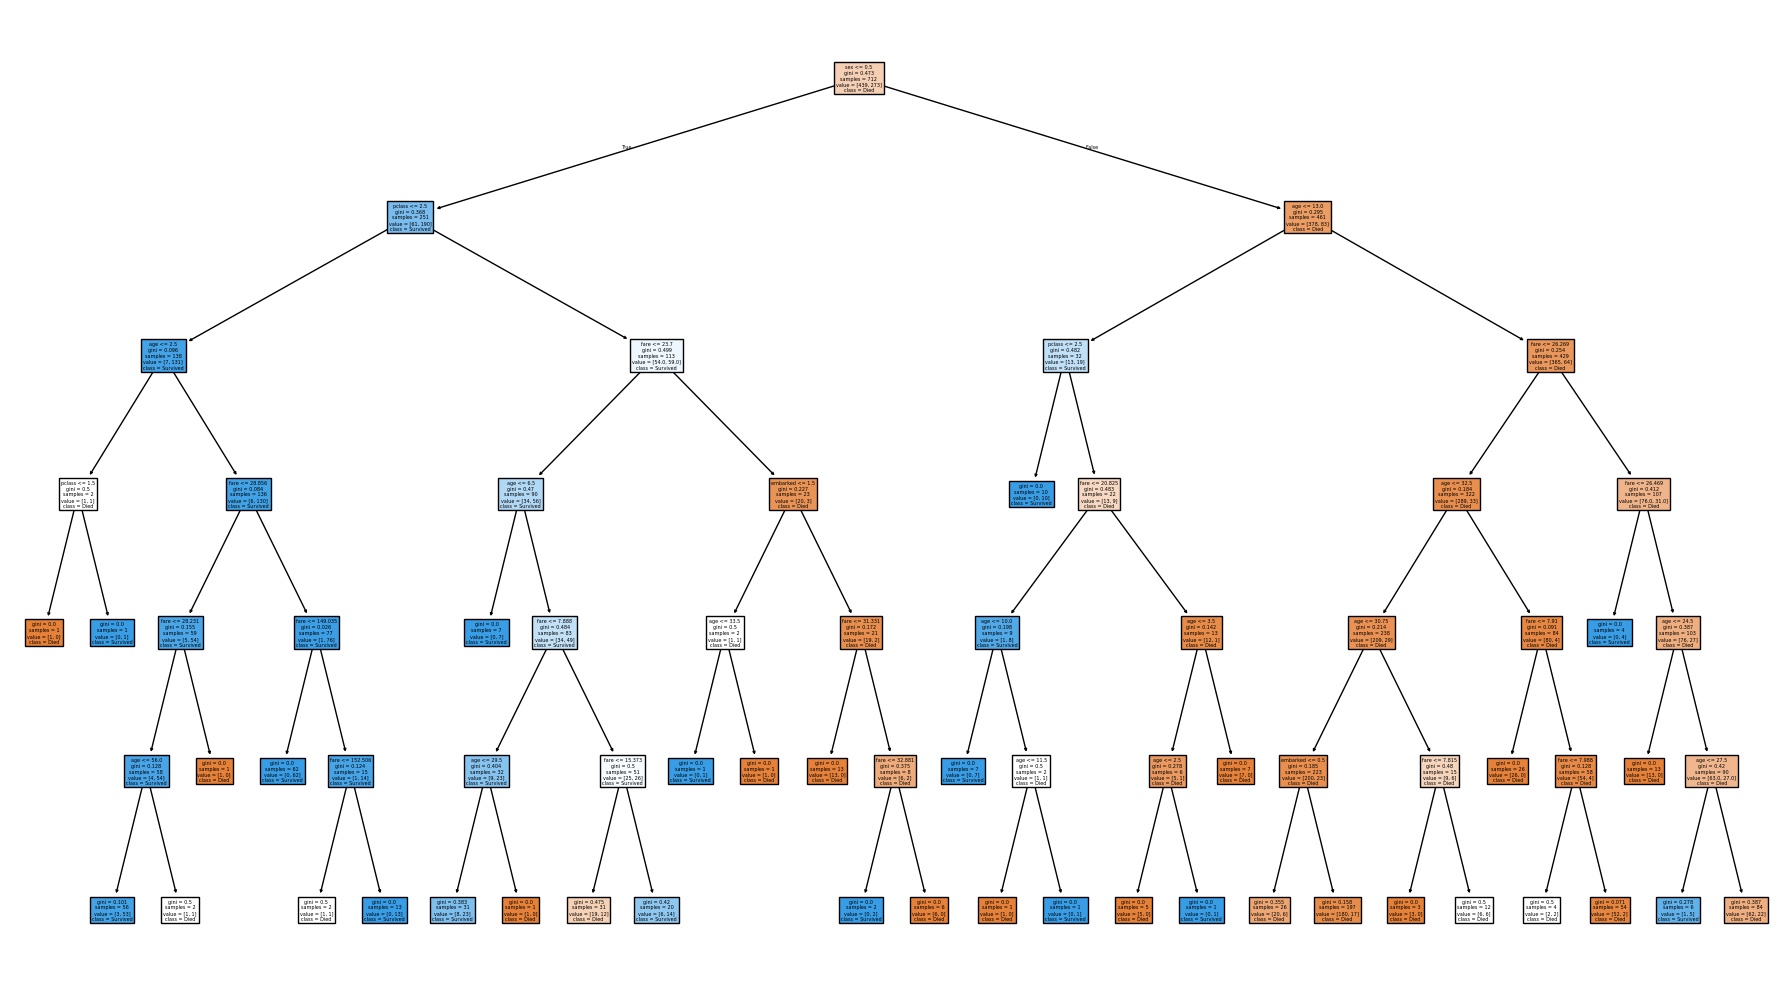

for depth = 7 , accuracy =0.8100558659217877
for depth = 8 , accuracy =0.8156424581005587
for depth = 9 , accuracy =0.8100558659217877
for depth = 10 , accuracy =0.8044692737430168


In [107]:
# pre-pruning
max_depth=[2,3,4,5,6,7,8,9,10]
for d in max_depth:
  model=DecisionTreeClassifier(max_depth=d)
  model.fit(x_train,y_train)
  acc=model.score(x_test,y_test)
  print(f"for depth = {d} , accuracy ={acc}")
  if d==6:
    plt.figure(figsize=(18,10))
    plot_tree(model,
              feature_names=X.columns ,
              class_names=["Died","Survived"],
              filled=True)
    plt.tight_layout()
    plt.show()


for sample split = 5 , accuracy =0.8156424581005587
for sample split = 10 , accuracy =0.8044692737430168
for sample split = 15 , accuracy =0.8156424581005587


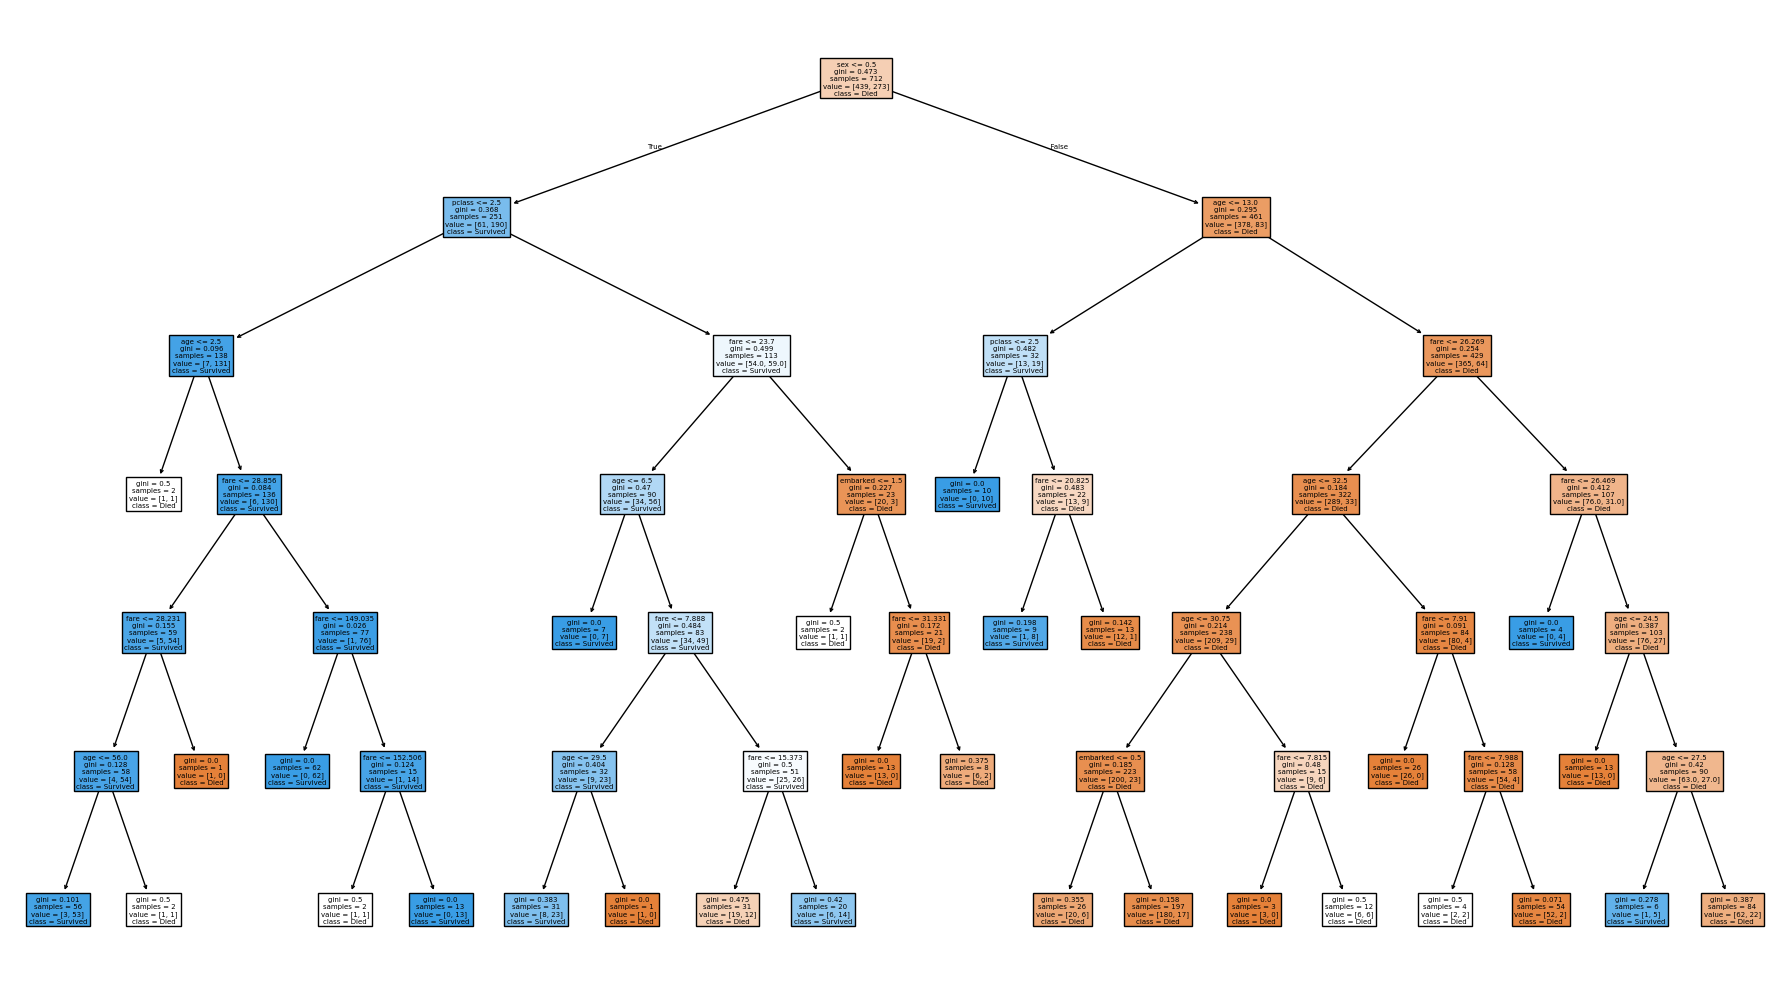

for sample split = 20 , accuracy =0.8156424581005587
for sample split = 25 , accuracy =0.8156424581005587


In [109]:
min_samples_splits=[5,10,15,20,25]
for d in min_samples_splits:
  model=DecisionTreeClassifier(max_depth=6,min_samples_split=d)
  model.fit(x_train,y_train)
  acc=model.score(x_test,y_test)
  print(f"for sample split = {d} , accuracy ={acc}")
  if d==15:
    plt.figure(figsize=(18,10))
    plot_tree(model,
              feature_names=X.columns ,
              class_names=["Died","Survived"],
              filled=True)
    plt.tight_layout()
    plt.show()

**Post Pruning**

In [124]:
ful_tree=DecisionTreeClassifier()
ful_tree.fit(x_train,y_train)

DecisionTreeClassifier()

In [111]:
path=ful_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 5.85205993e-05 9.29444812e-05
 9.93076836e-05 2.20037453e-04 3.00963082e-04 3.51123596e-04
 3.74531835e-04 4.21348315e-04 4.68164794e-04 4.68164794e-04
 7.57575758e-04 7.60767790e-04 7.80274657e-04 8.19288390e-04
 8.42696629e-04 8.73907615e-04 9.10320433e-04 9.22640559e-04
 9.24169463e-04 9.36329588e-04 9.83146067e-04 1.05337079e-03
 1.07075976e-03 1.07704952e-03 1.15852010e-03 1.17041199e-03
 1.19701226e-03 1.20385233e-03 1.24242716e-03 1.24276997e-03
 1.24843945e-03 1.27681307e-03 1.28477796e-03 1.29645635e-03
 1.35798920e-03 1.40449438e-03 1.40449438e-03 1.40449438e-03
 1.48280558e-03 1.48637023e-03 1.54786985e-03 1.58455776e-03
 1.60513644e-03 1.68539326e-03 1.86751451e-03 1.87265918e-03
 1.97443413e-03 2.03935422e-03 2.10674157e-03 2.10674157e-03
 2.14018192e-03 2.34082397e-03 2.34170267e-03 2.40265117e-03
 3.05867665e-03 3.13721501e-03 3.19370243e-03 4.00407518e-03
 5.88865588e-03 7.90873719e-03 8.29604521e-03 1.24450535e-02
 1.65321199e-02 3.184180

In [117]:
# train our model for all alphas
tree=[]
for alpha in ccp_alphas:
  model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
  model.fit(x_train,y_train)
  tree.append((model,alpha))


In [119]:
best_acc=0
best_alpha=0

for model,alpha in tree:
    acc=model.score(x_test,y_test)
    if acc>best_acc:
      best_acc=acc
      best_alpha=alpha
print(best_acc,best_alpha)

0.8156424581005587 0.0012768130745658838


0.8156424581005587


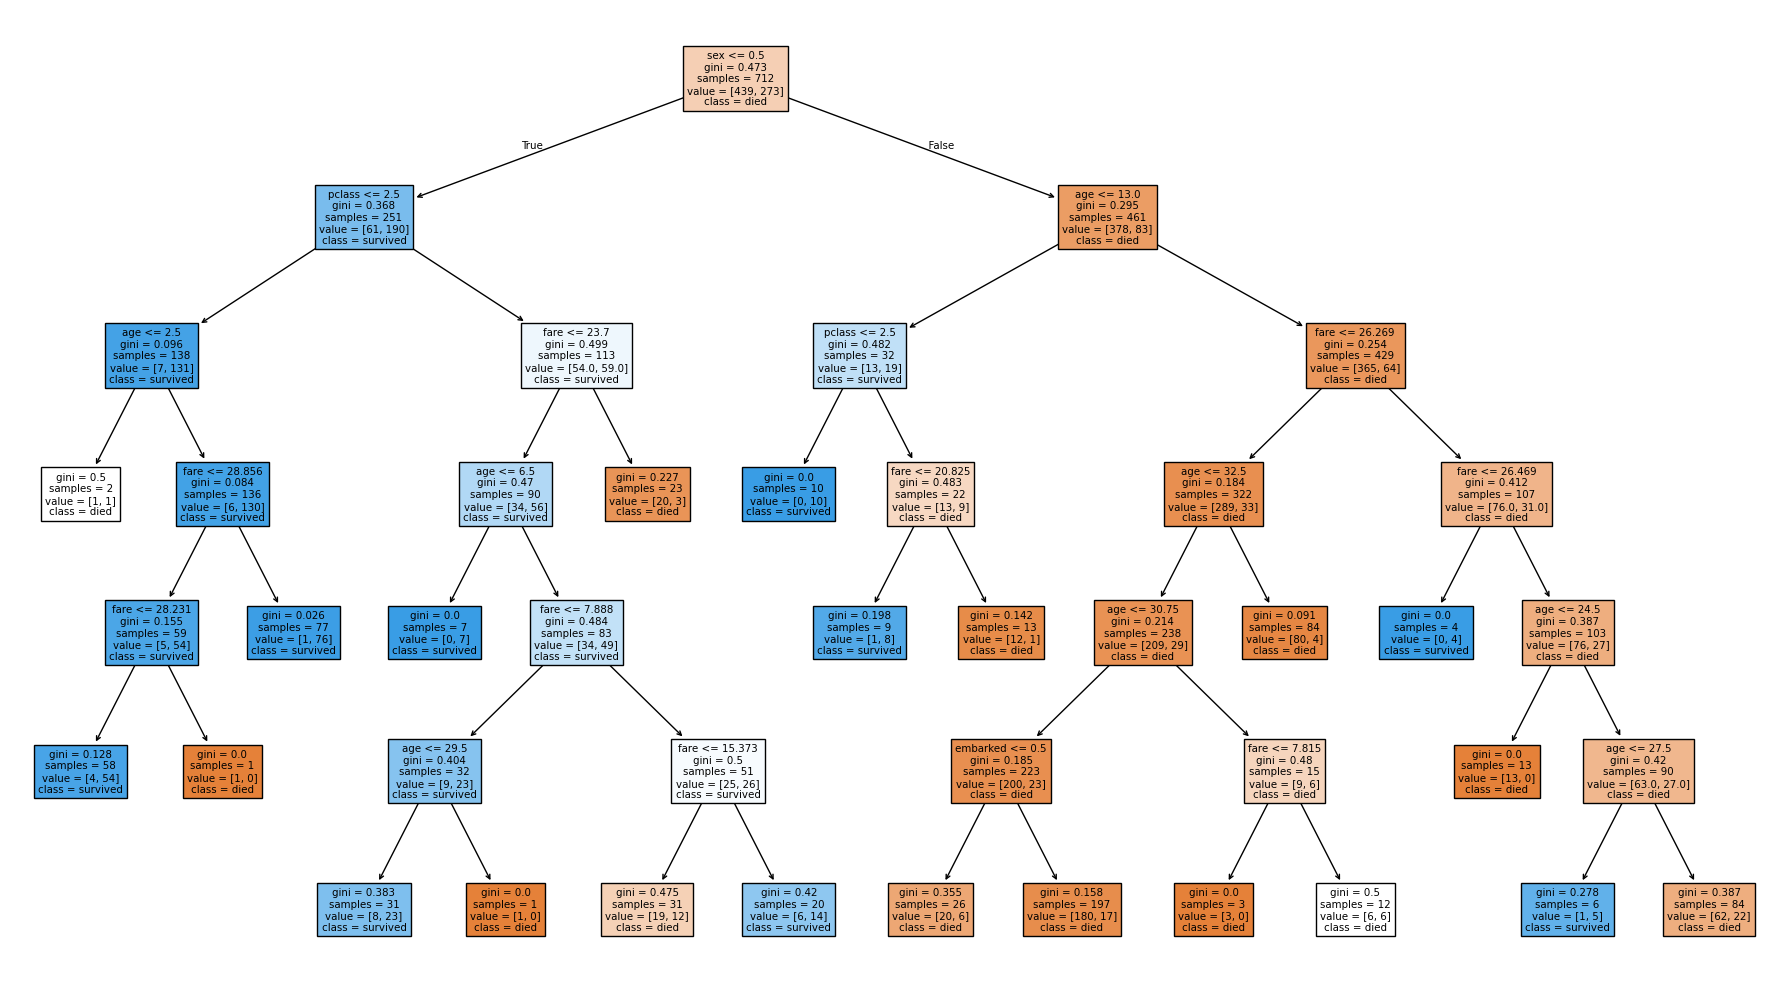

In [125]:
#best_model_after _pruning

final_model=DecisionTreeClassifier(ccp_alpha=best_alpha,max_depth=6,min_samples_split=15)
final_model.fit(x_train,y_train)

acc=final_model.score(x_test,y_test)
print(acc)

plt.figure(figsize=(18,10))
plot_tree(final_model,feature_names=X.columns,class_names=["died","survived"],filled=True)
plt.tight_layout()
plt.show()